# Grupo 1 | MCDI501 - Estadística Computacional para la Toma de Decisiones

## Integrantes
- Pablo Ignacio Balbontín Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Muñoz Carnot @dark452
- Mario Alejandro López Pulgar @malp2203

## Descripción del problema - Fase 4: Modelamiento Predictivo Integrado (Sumativa 3)

**Proyecto**: Predicción de la Deserción y el Éxito Académico de los Estudiantes

Este cuaderno integra los resultados de las Sumativas 1 y 2 en un modelo predictivo de
deserción estudiantil. El manejo de faltantes, la selección de variables, la lectura de la
colinealidad y la validación por bootstrap se fundamentan en los hallazgos de S1
(diagnóstico de calidad, correlaciones, pruebas de hipótesis) y S2 (correlaciones validadas
por bootstrap, pruebas confirmadas por permutación, observaciones influyentes por jackknife).

**Dataset:** *Predict Students' Dropout and Academic Success* (Realinho et al., 2022), UCI Repository.
$n = 4.424$ estudiantes, 37 variables.

**Estructura del cuaderno** (progresión S1 \$ \rightarrow \$ S2 \$ \rightarrow \$ S3 explícita en cada sección):

1. Manejo inteligente de datos faltantes
2. Clasificación mediante regresión logística
3. Análisis comparativo del impacto de la imputación
4. Síntesis integrada e informe final

**Semilla:** 42

## Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
sns.set_style('whitegrid')

COLORS_TARGET = {'Graduate': '#2ca02c', 'Dropout': '#d62728', 'Enrolled': '#1f77b4'}
BOOT_COLOR = '#4c72b0'
PERM_COLOR = '#dd8452'
FIG_DIR = '../data/processed'

print('Entorno configurado.')

Entorno configurado.


In [2]:
def load_data(file_path):
    """Carga el dataset raw desde un archivo CSV.

    Parámetros
    ----------
    file_path : str
        Ruta del archivo CSV utilizado como entrada.

    Retorno
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Excepción
    ---------
    FileNotFoundError
        Si la ruta al archivo CSV no existe. Se muestra un mensaje de error.
    """
    try:
        df = pd.read_csv(file_path, sep=';')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontro el archivo '{file_path}'. "
            "Verificar que el archivo CSV se encuentre en data/raw."
        )
    return df


df_full = load_data('../data/raw/predict_students_dropout_and_academic_success.csv')
df_full.columns = [c.strip() for c in df_full.columns]
print(f'Dataset cargado: {df_full.shape[0]:,} filas x {df_full.shape[1]} columnas')

Dataset cargado: 4,424 filas x 37 columnas


### Parámetros de referencia de las Sumativas 1 y 2

Los siguientes resultados, validados en la Sumativa 2 (sección 6, *"Preparación de insumos para la Sumativa 3"*), constituyen la base de las decisiones de modelamiento de esta fase.

In [3]:
# Correlaciones con el resultado académico validadas por bootstrap en S2 (IC 95%)
S2_CORR = {
    'Curricular units 2nd sem (grade)': {'lab': 'Nota 2do Semestre',    'r': 0.567, 'ci': (0.544, 0.589),   'clas': 'Robusta y relevante'},
    'Curricular units 1st sem (grade)': {'lab': 'Nota 1er Semestre',    'r': 0.485, 'ci': (0.461, 0.508),   'clas': 'Robusta y relevante'},
    'Age at enrollment':                {'lab': 'Edad al Matricularse', 'r': -0.243, 'ci': (-0.274, -0.213), 'clas': 'Robusta, relevancia moderada'},
    'Admission grade':                  {'lab': 'Nota de Admisión',     'r': 0.121, 'ci': (0.091, 0.150),   'clas': 'Robusta, relevancia baja'},
    'GDP':                              {'lab': 'PIB',                  'r': 0.044, 'ci': (0.016, 0.073),   'clas': 'Estable pero marginal'},
}

# Pruebas de hipótesis validadas por permutación en S2
S2_TESTS = {
    'Prueba 1': 'Nota de Admisión difiere entre Dropout y Graduate '
                '(Welch p=2.6e-14, permutación p=0.0001, Mann-Whitney p=3.3e-15)',
    'Prueba 2': 'Beca asociada al resultado académico '
                '(chi2 p=9.6e-90, permutación p=0.0001, V de Cramer=0.304)',
}

# Observaciones influyentes identificadas por jackknife en S2
S2_JACKKNIFE = ('Notas de admisión en el techo de escala (190) y estudiantes de 60-70 años, '
                'ningún caso altera las conclusiones al excluirlo.')

print('Referencias S1/S2 cargadas:')
for k, v in S2_CORR.items():
    print(f"  {v['lab']:<22} r={v['r']:+.3f}  IC=[{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]  ({v['clas']})")
for k, v in S2_TESTS.items():
    print(f'  {k}: {v}')

Referencias S1/S2 cargadas:
  Nota 2do Semestre      r=+0.567  IC=[+0.544, +0.589]  (Robusta y relevante)
  Nota 1er Semestre      r=+0.485  IC=[+0.461, +0.508]  (Robusta y relevante)
  Edad al Matricularse   r=-0.243  IC=[-0.274, -0.213]  (Robusta, relevancia moderada)
  Nota de Admisión       r=+0.121  IC=[+0.091, +0.150]  (Robusta, relevancia baja)
  PIB                    r=+0.044  IC=[+0.016, +0.073]  (Estable pero marginal)
  Prueba 1: Nota de Admisión difiere entre Dropout y Graduate (Welch p=2.6e-14, permutación p=0.0001, Mann-Whitney p=3.3e-15)
  Prueba 2: Beca asociada al resultado académico (chi2 p=9.6e-90, permutación p=0.0001, V de Cramer=0.304)


### Definición del problema de clasificación

La variable objetivo original tiene tres clases (Graduate $49{,}9\%$ , Dropout $32{,}1\%$, Enrolled
$17{,}9\%$). Para el modelamiento se adopta el problema **binario Dropout (1) vs. Graduate (0)**,
excluyendo a los estudiantes Enrolled, por tres razones:

1. *Enrolled* no es un resultado terminal: son estudiantes aún matriculados al cierre del
   período, cuyo desenlace (graduarse o desertar) todavía no se observa, incluirlos como
   clase contaminaría el aprendizaje con etiquetas censuradas.
2. Toda la evidencia inferencial de S1 y S2 (pruebas de Welch, permutación y Mann-Whitney)
   se construyó comparando precisamente Dropout vs. Graduate, de modo que el modelo hereda
   directamente esas señales validadas.
3. La decisión de negocio que motiva el proyecto (intervención temprana de retención)
   requiere distinguir quién abandonará de quién se graduará.

In [4]:
df = df_full[df_full['Target'].isin(['Dropout', 'Graduate'])].copy()
df['y'] = (df['Target'] == 'Dropout').astype(int)
print(f'Subconjunto de modelamiento: {len(df):,} estudiantes')
print(f'  Graduate (0): {(df.y == 0).sum():,} ({(df.y == 0).mean() * 100:.1f}%)')
print(f'  Dropout  (1): {(df.y == 1).sum():,} ({df.y.mean() * 100:.1f}%)')
print('Desbalance moderado: no requiere ponderación de clases (a diferencia del caso')

Subconjunto de modelamiento: 3,630 estudiantes
  Graduate (0): 2,209 (60.9%)
  Dropout  (1): 1,421 (39.1%)
Desbalance moderado: no requiere ponderación de clases (a diferencia del caso


## Sección 1 - Manejo inteligente de datos faltantes

### 1.1 Referencia al análisis de faltantes de S1 y diagnóstico de faltantes ocultos

S1 reportó **cero valores faltantes explícitos** (ningún `NaN` en las 37 columnas). Sin
embargo, el diagnóstico de calidad de S1 (sección 1.3) dejó registrado el rango
`[0, 18.9]` de las notas semestrales, y una inspección más fina revela que el 0 no es una
nota real: en la escala portuguesa las notas de aprobación van de 10 a 20, y **todos** los
registros con nota semestral 0 tienen además 0 unidades curriculares aprobadas. Se trata de
**ceros estructurales**: estudiantes que no completaron evaluaciones en el semestre, para
quienes la nota promedio *no existe*. Codificarlos como 0 contamina la variable (mezcla
"no tiene nota" con "nota pésima") y distorsiona medias, correlaciones y coeficientes.

Siguiendo la práctica de manejo inteligente de faltantes, estos ceros estructurales se
recodifican como faltantes (`NaN`) y se tratan con las estrategias de imputación de esta
sección.

In [5]:
G1, G2 = 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'
A1, A2 = 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)'

# ceros estructurales: nota 0 sin ninguna unidad aprobada
falt1 = (df[G1] == 0) & (df[A1] == 0)
falt2 = (df[G2] == 0) & (df[A2] == 0)
print('Faltantes ocultos (nota 0 con 0 unidades aprobadas):')
print(f'  Nota 1er semestre: {falt1.sum():,} ({falt1.mean() * 100:.1f}%)')
print(f'  Nota 2do semestre: {falt2.sum():,} ({falt2.mean() * 100:.1f}%)')
print(f'  Casos con nota 0 y aprobadas > 0 (inconsistencias): '
      f'{((df[G1] == 0) & (df[A1] > 0)).sum()}')

# evidencia sobre el mecanismo: el faltante se asocia a variables observadas
print('\nPerfil observado de los estudiantes con nota faltante (2do semestre):')
comp_vars = [('Tasa de deserción', df.loc[falt2, 'y'].mean(), df.loc[~falt2, 'y'].mean()),
             ('Matrícula al día', df.loc[falt2, 'Tuition fees up to date'].mean(),
              df.loc[~falt2, 'Tuition fees up to date'].mean()),
             ('Becado', df.loc[falt2, 'Scholarship holder'].mean(),
              df.loc[~falt2, 'Scholarship holder'].mean()),
             ('Deudor', df.loc[falt2, 'Debtor'].mean(), df.loc[~falt2, 'Debtor'].mean()),
             ('Edad promedio', df.loc[falt2, 'Age at enrollment'].mean(),
              df.loc[~falt2, 'Age at enrollment'].mean())]
print(f'{"Indicador":<20}{"Con faltante":>14}{"Sin faltante":>14}')
for lab, a, b in comp_vars:
    print(f'{lab:<20}{a:>14.3f}{b:>14.3f}')

# recodificacion como NaN
df.loc[falt1, G1] = np.nan
df.loc[falt2, G2] = np.nan
print(f'\nRecodificados como NaN => faltantes: {G1.split("(")[0].strip()}: '
      f'{int(df[G1].isna().sum())}, 2do sem: {int(df[G2].isna().sum())}')

Faltantes ocultos (nota 0 con 0 unidades aprobadas):
  Nota 1er semestre: 647 (17.8%)
  Nota 2do semestre: 802 (22.1%)
  Casos con nota 0 y aprobadas > 0 (inconsistencias): 0

Perfil observado de los estudiantes con nota faltante (2do semestre):
Indicador             Con faltante  Sin faltante
Tasa de deserción            0.906         0.245
Matrícula al día             0.676         0.920
Becado                       0.102         0.314
Deudor                       0.191         0.092
Edad promedio               26.108        22.710

Recodificados como NaN => faltantes: Curricular units 1st sem: 647, 2do sem: 802


**Verificación empírica: ¿es 0 una nota real o un centinela?** Antes de recodificar, se comprueba que el 0 no puede ser una nota reprobatoria genuina.

In [6]:
# (a) hueco en la distribucion: ninguna nota real cae entre 0 y la minima nota positiva
for g, lab in [(G1, '1er semestre'), (G2, '2do semestre')]:
    positivas = np.sort(df_full.loc[df_full[g] > 0, g].unique())
    print(f'Nota {lab}: minima nota positiva registrada = {positivas[0]:.2f} '
          f'=> ningun valor entre 0 y {positivas[0]:.2f} (hueco en la distribucion)')

# (b) estudiantes con nota 0 que igual se graduaron: imposible si 0 fuera nota real
sub_gd = df_full[df_full['Target'].isin(['Dropout', 'Graduate'])]
for g, lab in [(G1, '1er semestre'), (G2, '2do semestre')]:
    grad_cero = int(((sub_gd[g] == 0) & (sub_gd['Target'] == 'Graduate')).sum())
    print(f'Nota {lab} = 0 en estudiantes que se graduaron: {grad_cero} '
          f'(si 0 fuera nota reprobatoria real, graduarse con promedio 0 no seria posible)')

Nota 1er semestre: minima nota positiva registrada = 9.80 => ningun valor entre 0 y 9.80 (hueco en la distribucion)
Nota 2do semestre: minima nota positiva registrada = 10.00 => ningun valor entre 0 y 10.00 (hueco en la distribucion)
Nota 1er semestre = 0 en estudiantes que se graduaron: 77 (si 0 fuera nota reprobatoria real, graduarse con promedio 0 no seria posible)
Nota 2do semestre = 0 en estudiantes que se graduaron: 75 (si 0 fuera nota reprobatoria real, graduarse con promedio 0 no seria posible)


La verificación empírica anterior confirma que el 0 no es una nota reprobatoria genuina:
existe un hueco entre 0 y la nota positiva más baja ($9,80$ y $10,00$), y decenas de estudiantes
con nota 0 igualmente se graduaron ($77$ y $75$ casos), imposible si 0 fuera un promedio real.
El 0 es, en efecto, un centinela de 'sin evaluación', no un dato válido en la escala $0 - 20$.

**Diagnóstico del mecanismo.** De los tres mecanismos clásicos (Little & Rubin, 2019),
**MCAR** se descarta de inmediato: la ausencia de nota está fuertemente asociada al abandono
($90{,}6\%$ de deserción entre quienes no tienen nota del 2do semestre vs. $24{,}5\%$ entre quienes
sí la tienen) y a variables administrativas observadas (matrícula al día, deuda, beca,
edad). 
El mecanismo tiene además un componente **MNAR** irreducible: el estudiante no tiene
nota *porque* abandonó, es decir, la ausencia depende del propio desenlace. Adoptamos como
supuesto de trabajo el **MAR condicional**: la ausencia se explica por el desempeño y las
condiciones administrativas observadas (unidades aprobadas, matrícula al día, deuda, notas
previas), todas disponibles en el dataset. Es un supuesto, no una certeza, y lo declaramos
como tal, su implicancia práctica se evalúa empíricamente en la Sección 3, donde se
comparan las estrategias de manejo.

### 1.2 Imputación mediante regresión lineal múltiple

Los predictores de cada regresión se eligen con las correlaciones observadas en S1,
priorizando las que S2 validó como estables: la nota de admisión ($r = +0,34$ con la nota
del 1er semestre en casos completos), la nota de la titulación previa ($r = +0,30$), la edad
($r = −0,12$, dirección coherente con la correlación robusta de S2) y las unidades aprobadas
del semestre correspondiente, que es el indicador de desempeño observado para *todos* los
estudiantes, incluidos los que no tienen nota. Se ajusta sobre casos completos, se
verifican los supuestos con los residuos y se documenta el encogimiento de varianza propio
del método.

In [7]:
comp = df.dropna(subset=[G1, G2])
pred_g1 = ['Admission grade', 'Previous qualification (grade)', 'Age at enrollment', A1]
pred_g2 = ['Admission grade', 'Previous qualification (grade)', 'Age at enrollment', A2]

print('Correlaciones (casos completos) que justifican los predictores:')
print('  Nota 1er sem vs', {p.split('(')[0].strip(): round(np.corrcoef(comp[G1], comp[p])[0, 1], 3)
                            for p in pred_g1})
print('  Nota 2do sem vs', {p.split('(')[0].strip(): round(np.corrcoef(comp[G2], comp[p])[0, 1], 3)
                            for p in pred_g2})

lm1 = LinearRegression().fit(comp[pred_g1], comp[G1])
lm2 = LinearRegression().fit(comp[pred_g2], comp[G2])
pred = lm1.predict(comp[pred_g1])
resid = comp[G1].values - pred

print(f'\nAjuste: R2 nota 1er sem = {lm1.score(comp[pred_g1], comp[G1]):.3f} | '
      f'R2 nota 2do sem = {lm2.score(comp[pred_g2], comp[G2]):.3f}')
print('Verificación de supuestos (regresión de la nota del 1er semestre):')
print(f'  residuos: media = {resid.mean():.3f}, sd = {resid.std():.3f}, '
      f'asimetría = {stats.skew(resid):.2f}')
print(f'  corr(residuo, ajustado) = {np.corrcoef(resid, pred)[0, 1]:.3f} '
      '=> linealidad en media OK')
print(f'  encogimiento: sd(observado) = {comp[G1].std():.3f} vs sd(imputado) = '
      f'{pred.std():.3f} ({(1 - pred.std() / comp[G1].std()) * 100:.0f}% menos)')
print(f'  valores a imputar: 1er sem = {int(df[G1].isna().sum())}, '
      f'2do sem = {int(df[G2].isna().sum())}')

Correlaciones (casos completos) que justifican los predictores:
  Nota 1er sem vs {'Admission grade': np.float64(0.335), 'Previous qualification': np.float64(0.299), 'Age at enrollment': np.float64(-0.117), 'Curricular units 1st sem': np.float64(0.191)}
  Nota 2do sem vs {'Admission grade': np.float64(0.302), 'Previous qualification': np.float64(0.273), 'Age at enrollment': np.float64(-0.094), 'Curricular units 2nd sem': np.float64(0.302)}

Ajuste: R2 nota 1er sem = 0.166 | R2 nota 2do sem = 0.183
Verificación de supuestos (regresión de la nota del 1er semestre):
  residuos: media = -0.000, sd = 1.210, asimetría = 0.38
  corr(residuo, ajustado) = 0.000 => linealidad en media OK
  encogimiento: sd(observado) = 1.326 vs sd(imputado) = 0.540 (59% menos)
  valores a imputar: 1er sem = 647, 2do sem = 802


#### Figura 13. Imputación: encogimiento de varianza y diagnóstico de residuos

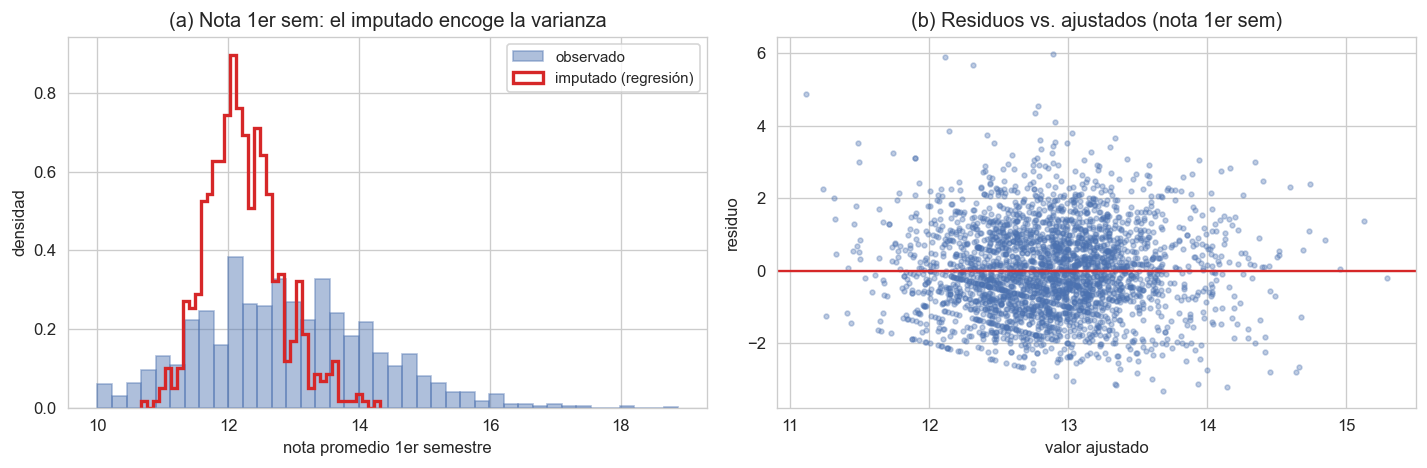

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

obs = comp[G1]
imp = np.clip(lm1.predict(df.loc[df[G1].isna(), pred_g1]), 0, 20)
ax[0].hist(obs, bins=40, color=BOOT_COLOR, alpha=0.45, density=True,
           edgecolor=BOOT_COLOR, label='observado')
ax[0].hist(imp, bins=40, color='#d62728', histtype='step', lw=2, density=True,
           label='imputado (regresión)')
ax[0].set_title('(a) Nota 1er sem: el imputado encoge la varianza')
ax[0].set_xlabel('nota promedio 1er semestre')
ax[0].set_ylabel('densidad')
ax[0].legend(fontsize=9)

ax[1].scatter(pred, resid, s=8, color=BOOT_COLOR, alpha=0.35)
ax[1].axhline(0, color='#d62728', lw=1.4)
ax[1].set_title('(b) Residuos vs. ajustados (nota 1er sem)')
ax[1].set_xlabel('valor ajustado')
ax[1].set_ylabel('residuo')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig13_imputacion.png', dpi=150, bbox_inches='tight')
plt.show()

Los residuos tienen media cero, no correlacionan con el valor ajustado (linealidad en
media razonable) y su asimetría es moderada ($0,38$). El ajuste es débil por construcción ($R² = 0,17$ y $0,18$): las notas
semestrales dependen de factores no observados (esfuerzo, asistencia), y las variables
pre-matrícula solo explican una fracción. La limitación más relevante es el
**encogimiento de varianza**: la regresión reemplaza cada faltante por su predicción
condicional, y los valores imputados tienen un $59\%$ menos de dispersión que los observados
(pico estrecho de la Figura 13a). Una imputación múltiple restauraría esa variabilidad;
lo asumimos como costo conocido del método y lo declaramos como limitación.

### 1.3 Comparación de estrategias de imputación

In [9]:
# tres estrategias: eliminacion, imputacion simple (mediana), imputacion por regresion
df_del = df.dropna(subset=[G1, G2]).copy()

df_simple = df.copy()
for g in [G1, G2]:
    df_simple[g] = df_simple[g].fillna(df_simple[g].median())

df_reg = df.copy()
mi1 = df_reg[G1].isna()
df_reg.loc[mi1, G1] = np.clip(lm1.predict(df_reg.loc[mi1, pred_g1]), 0, 20)
mi2 = df_reg[G2].isna()
df_reg.loc[mi2, G2] = np.clip(lm2.predict(df_reg.loc[mi2, pred_g2]), 0, 20)

tab = [[nm, len(d_), d_['y'].mean(), d_[G2].mean(), d_[G2].std(),
        np.corrcoef(d_[G2], d_['y'])[0, 1]]
       for nm, d_ in [('Eliminación', df_del), ('Imputación simple (mediana)', df_simple),
                      ('Imputación regresión', df_reg)]]
print(pd.DataFrame(tab, columns=['Estrategia', 'n', 'Tasa deserción', 'Media nota 2do',
                                 'Desv.', 'corr(nota, deserción)'])
        .set_index('Estrategia').round(3).to_string())

                                n  Tasa deserción  Media nota 2do  Desv.  corr(nota, deserción)
Estrategia                                                                                     
Eliminación                  2802           0.239          12.894  1.371                 -0.325
Imputación simple (mediana)  3630           0.391          12.872  1.215                 -0.268
Imputación regresión         3630           0.391          12.658  1.306                 -0.439


La comparación revela diferencias mucho más severas que en el ejemplo del curso, porque
aquí el faltante es informativo. La **eliminación** descarta $828$ estudiantes ($22{,}8\%$) y,
como el $90\%$ de ellos son desertores, **sesga la tasa de deserción de $39{,}1\%$ a $23{,}9\%$**:
inaceptable cuando el faltante se concentra en la clase de interés. La **imputación
simple** conserva el tamaño pero asigna la nota mediana ($ \sim \! 12{,}6 $) a estudiantes cuyo
desempeño observado fue nulo, atenuando la correlación con la deserción ($−0,27$). 

La **imputación por regresión** conserva el tamaño completo y, al usar las unidades aprobadas
como predictor, asigna notas bajas coherentes con el desempeño observado, preservando la
señal ($−0,44$). Se adopta la **imputación por regresión** para el resto del desarrollo,
asumiendo el encogimiento de varianza como limitación declarada. El impacto de esta
decisión sobre el modelo final se cuantifica en la Sección 3.

## Sección 2 - Clasificación mediante regresión logística

### 2.1 Preparación de datos informada por S1 y S2

Sobre el conjunto imputado se realiza una partición **70/30 estratificada** por la variable
objetivo, que preserva la tasa de deserción ($39{,}1\%$) en ambos conjuntos. Los predictores se
**estandarizan** (media 0, desviación 1) con parámetros aprendidos solo en entrenamiento,
de modo que los coeficientes y odds ratios se interpretan *por desviación estándar* y son
comparables entre sí. El desbalance es moderado ($39/61$), por lo que no se requiere
ponderación de clases ni ajuste de umbral.

El conjunto de 14 candidatos combina los tres bloques que S1 caracterizó: desempeño
académico (notas y unidades aprobadas de ambos semestres, nota de admisión, nota de la
titulación previa), condición socioeconómica y administrativa (beca, deuda, matrícula al
día, género, edad) y contexto macroeconómico (desempleo, inflación, PIB), estas últimas
incluidas deliberadamente pese a que S2 las clasificó como marginales, para que la
selección de variables las evalúe formalmente.

In [10]:
FEATURES = ['Curricular units 2nd sem (grade)', 'Curricular units 1st sem (grade)',
            'Curricular units 2nd sem (approved)', 'Curricular units 1st sem (approved)',
            'Admission grade', 'Previous qualification (grade)', 'Age at enrollment',
            'Scholarship holder', 'Debtor', 'Tuition fees up to date', 'Gender',
            'Unemployment rate', 'Inflation rate', 'GDP']
short = {'Curricular units 2nd sem (grade)': 'Nota2doSem',
         'Curricular units 1st sem (grade)': 'Nota1erSem',
         'Curricular units 2nd sem (approved)': 'Aprob2doSem',
         'Curricular units 1st sem (approved)': 'Aprob1erSem',
         'Admission grade': 'NotaAdmision',
         'Previous qualification (grade)': 'NotaPrevia',
         'Age at enrollment': 'Edad',
         'Scholarship holder': 'Beca',
         'Debtor': 'Deudor',
         'Tuition fees up to date': 'MatriculaAlDia',
         'Gender': 'Genero',
         'Unemployment rate': 'Desempleo',
         'Inflation rate': 'Inflacion',
         'GDP': 'PIB'}

X = df_reg[FEATURES].values
y = df_reg['y'].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
print(f'train = {len(ytr):,} (deserción {ytr.mean() * 100:.2f}%)  |  '
      f'test = {len(yte):,} (deserción {yte.mean() * 100:.2f}%)')

train = 2,541 (deserción 39.16%)  |  test = 1,089 (deserción 39.12%)


### 2.2 Selección de variables informada por S1 y S2

Se construyen tres modelos:

1. **M1 (dominio S1/S2)**: solo las cinco señales que S1 destacó y S2 validó como robustas
   (notas de ambos semestres, edad, nota de admisión y beca, las cuatro correlaciones estables más la asociación de la beca confirmada por permutación).
2. **M2 (stepwise AIC/BIC)**: selección hacia adelante sobre los 14 candidatos.
3. **M3 (reducido informado)**: el conjunto donde el BIC alcanza su mínimo, coincidente
   con la eliminación hacia atrás de las variables que S1/S2 caracterizaron como débiles
   o redundantes (macroeconómicas marginales, nota previa colineal con la de admisión,
   duplicados del 1er semestre).

La trayectoria AIC/BIC muestra el razonamiento, y la comparación se valida con validación
cruzada de 5 particiones.


In [11]:
rem = list(range(len(FEATURES)))
sel, traj = [], []
while rem:
    best = None
    for c in rem:
        f = sm.Logit(ytr, sm.add_constant(Xtr_s[:, sel + [c]])).fit(disp=0, maxiter=200)
        if best is None or f.aic < best[0]:
            best = (f.aic, f.bic, c)
    sel.append(best[2])
    rem.remove(best[2])
    traj.append([len(sel), short[FEATURES[best[2]]], best[0], best[1]])

traj_df = pd.DataFrame(traj, columns=['paso', 'variable agregada', 'AIC', 'BIC']).set_index('paso')
print(traj_df.round(1).to_string())
print(f'\nPenalización BIC por variable = ln(n) = {np.log(len(ytr)):.2f}')
print(f'Mínimo AIC en el paso {traj_df.AIC.idxmin()} | Mínimo BIC en el paso {traj_df.BIC.idxmin()}')

     variable agregada     AIC     BIC
paso                                  
1          Aprob2doSem  2033.7  2045.4
2       MatriculaAlDia  1822.9  1840.5
3                 Beca  1758.2  1781.6
4           Nota2doSem  1710.0  1739.2
5                 Edad  1683.2  1718.3
6               Deudor  1667.4  1708.3
7               Genero  1654.8  1701.5
8            Desempleo  1649.1  1701.7
9         NotaAdmision  1643.5  1701.9
10         Aprob1erSem  1640.8  1705.0
11          Nota1erSem  1640.8  1710.8
12           Inflacion  1641.6  1717.5
13          NotaPrevia  1643.3  1725.1
14                 PIB  1645.3  1732.9

Penalización BIC por variable = ln(n) = 7.84
Mínimo AIC en el paso 11 | Mínimo BIC en el paso 7


La penalización $ \ln(n) \approx 7{,}8 $ discrimina: el **AIC alcanza su mínimo con
11 variables y el BIC con 7**. Las incorporaciones posteriores al paso 7 (desempleo, nota
de admisión, duplicados del 1er semestre, inflación, nota previa, PIB) no compensan la
penalización del BIC: son exactamente las variables que S2 clasificó como marginales
(PIB, $r = 0,04$) o que duplican información ya presente (la nota del 1er semestre
correlaciona $0,70$ con la del 2do, la nota previa $0,58$ con la de admisión). El criterio
estadístico y el juicio informado por S1/S2 convergen en el mismo conjunto reducido.

In [12]:
def fit_eval(idx, name):
    """Ajusta regresión logística sin penalización y evalúa en train/test."""
    m = LogisticRegression(penalty=None, max_iter=3000).fit(Xtr_s[:, idx], ytr)
    ptr = m.predict_proba(Xtr_s[:, idx])[:, 1]
    pte = m.predict_proba(Xte_s[:, idx])[:, 1]
    yhat = (pte >= 0.5).astype(int)
    return {'name': name, 'idx': idx, 'model': m,
            'auc_tr': roc_auc_score(ytr, ptr), 'auc': roc_auc_score(yte, pte),
            'acc': accuracy_score(yte, yhat), 'prec': precision_score(yte, yhat),
            'rec': recall_score(yte, yhat), 'f1': f1_score(yte, yhat),
            'pte': pte, 'yhat': yhat, 'yhat_tr': (ptr >= 0.5).astype(int)}

idx1 = [FEATURES.index(c) for c in ['Curricular units 2nd sem (grade)',
                                    'Curricular units 1st sem (grade)',
                                    'Age at enrollment', 'Admission grade',
                                    'Scholarship holder']]
idx2 = [c for c in sel[:traj_df.AIC.idxmin()]]          # stepwise: minimo AIC
idx3 = [c for c in sel[:traj_df.BIC.idxmin()]]          # reducido: minimo BIC + dominio

M1 = fit_eval(idx1, 'M1 (dominio S1/S2)')
M2 = fit_eval(idx2, 'M2 (stepwise AIC)')
M3 = fit_eval(idx3, 'M3 (reducido BIC + dominio)')

cvk = StratifiedKFold(5, shuffle=True, random_state=SEED)
for M in [M1, M2, M3]:
    cv = cross_val_score(LogisticRegression(penalty=None, max_iter=3000),
                         Xtr_s[:, M['idx']], ytr, cv=cvk, scoring='roc_auc')
    M['cv'], M['cv_sd'] = cv.mean(), cv.std()

print('M1 (dominio):  ', [short[FEATURES[i]] for i in idx1])
print('M2 (stepwise): ', [short[FEATURES[i]] for i in idx2])
print('M3 (reducido): ', [short[FEATURES[i]] for i in idx3])
perf = pd.DataFrame([[M['name'], len(M['idx']), M['auc_tr'], M['auc'],
                      f"{M['cv']:.3f} ± {M['cv_sd']:.3f}", M['acc'], M['prec'],
                      M['rec'], M['f1']] for M in [M1, M2, M3]],
                    columns=['Modelo', 'Vars', 'AUC train', 'AUC test', 'CV-AUC (5 part.)',
                             'Acc', 'Prec', 'Recall', 'F1']).set_index('Modelo')
print('\n' + perf.round(3).to_string())
best = M3

M1 (dominio):   ['Nota2doSem', 'Nota1erSem', 'Edad', 'NotaAdmision', 'Beca']
M2 (stepwise):  ['Aprob2doSem', 'MatriculaAlDia', 'Beca', 'Nota2doSem', 'Edad', 'Deudor', 'Genero', 'Desempleo', 'NotaAdmision', 'Aprob1erSem', 'Nota1erSem']
M3 (reducido):  ['Aprob2doSem', 'MatriculaAlDia', 'Beca', 'Nota2doSem', 'Edad', 'Deudor', 'Genero']

                             Vars  AUC train  AUC test CV-AUC (5 part.)    Acc   Prec  Recall     F1
Modelo                                                                                              
M1 (dominio S1/S2)              5      0.827     0.828    0.826 ± 0.011  0.772  0.719   0.685  0.702
M2 (stepwise AIC)              11      0.925     0.939    0.923 ± 0.012  0.903  0.883   0.866  0.874
M3 (reducido BIC + dominio)     7      0.923     0.938    0.923 ± 0.012  0.898  0.880   0.857  0.868


Los tres modelos provienen de criterios distintos y la validación cruzada confirma el 
ranking de forma robusta. La lectura clave es de **parsimonia**: el modelo reducido de $7$ 
variables ($M3$) iguala al stepwise de $11$ AUC test $0{,}938$ vs. $0{,}939$, 
CV-AUC $0{,}923$ en ambos) y ambos superan con claridad al de dominio puro ($0{,}828$), 
que ignora las variables administrativas (matrícula al día, deuda) cuya fuerza S1 ya insinuaba. 
A diferencia del ejemplo del curso, donde a ese tamaño muestral la selección automática no 
podía podar y el modelo completo fue la referencia, aquí AIC/BIC y el juicio 
de dominio convergen, y se adopta **$M3$ como modelo final**: mismo desempeño con menos 
variables, más interpretable y operativamente más barato de poblar.

### 2.3 Evaluación de estabilidad mediante bootstrap

Siguiendo el enfoque de S2, se aplica bootstrap al modelo final: **500 remuestras** del
conjunto de entrenamiento con reajuste completo del modelo en cada una, e intervalos
percentil al $95\%$ para los coeficientes y los odds ratios, comparados con los intervalos de
Wald. Se usan $500$ remuestras (no $10.000$ como en S2) porque allí cada remuestra recalculaba
una media o una correlación, una operación directa, mientras que aquí cada remuestra
reajusta una regresión logística completa por máxima verosimilitud, con $500$ el intervalo
percentil al $95\%$ ya es estable para este tamaño muestral (Efron & Tibshirani, 1993).

In [13]:
idxb = best['idx']
Xtr_b = Xtr_s[:, idxb]
sm_fit = sm.Logit(ytr, sm.add_constant(Xtr_b)).fit(disp=0, maxiter=300)
names_b = ['const'] + [short[FEATURES[i]] for i in idxb]

B, ntr = 500, len(ytr)
boot = np.zeros((B, len(idxb) + 1))
for b in range(B):
    ii = rng.integers(0, ntr, ntr)
    mb = LogisticRegression(penalty=None, max_iter=1000).fit(Xtr_b[ii], ytr[ii])
    boot[b, 0] = mb.intercept_[0]
    boot[b, 1:] = mb.coef_[0]

ciw = sm_fit.conf_int()
rows = []
for i, nm in enumerate(names_b):
    cl, ch = np.percentile(boot[:, i], [2.5, 97.5])
    orb = np.exp(boot[:, i])
    ol, oh = np.percentile(orb, [2.5, 97.5])
    estable = 'Sí' if (ol > 1) == (oh > 1) else 'REVISAR'
    rows.append([nm, sm_fit.params[i], ciw[i, 0], ciw[i, 1], cl, ch,
                 np.exp(sm_fit.params[i]), ol, oh, estable])
tab_boot = pd.DataFrame(rows, columns=['Variable', 'coef', 'WaldInf', 'WaldSup',
                                       'BootInf', 'BootSup', 'OR', 'ORbootInf',
                                       'ORbootSup', 'Estable']).set_index('Variable')
print(tab_boot.round(3).to_string())

                 coef  WaldInf  WaldSup  BootInf  BootSup     OR  ORbootInf  ORbootSup Estable
Variable                                                                                      
const          -0.651   -0.788   -0.514   -0.790   -0.501  0.521      0.454      0.606      Sí
Aprob2doSem    -1.731   -1.904   -1.559   -1.945   -1.535  0.177      0.143      0.215      Sí
MatriculaAlDia -0.851   -1.049   -0.654   -1.108   -0.674  0.427      0.330      0.510      Sí
Beca           -0.469   -0.610   -0.328   -0.631   -0.326  0.626      0.532      0.722      Sí
Nota2doSem     -0.507   -0.651   -0.362   -0.671   -0.355  0.602      0.511      0.701      Sí
Edad            0.307    0.186    0.428    0.191    0.429  1.359      1.211      1.536      Sí
Deudor          0.311    0.169    0.453    0.171    0.456  1.365      1.186      1.578      Sí
Genero          0.242    0.118    0.365    0.121    0.374  1.273      1.129      1.454      Sí


#### Figura 14. Odds ratios del modelo final con IC bootstrap al 95%

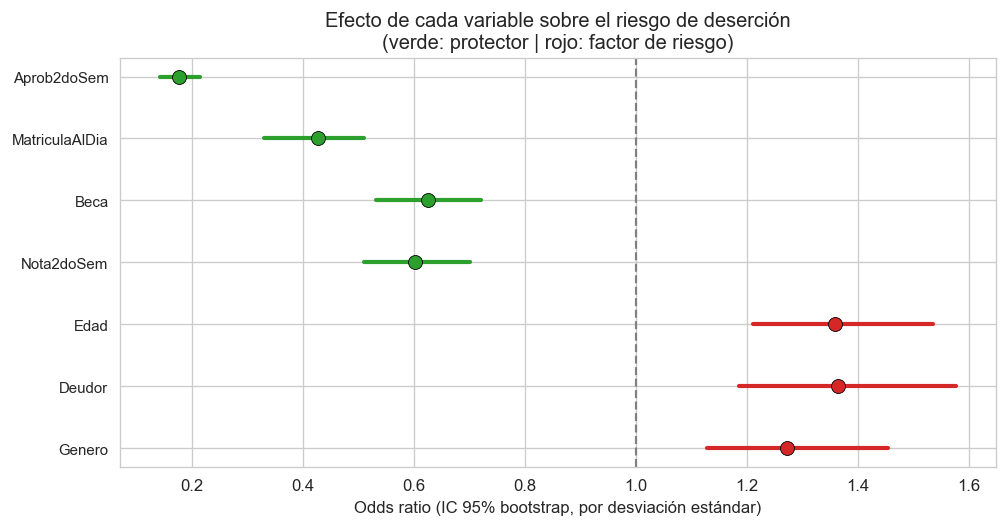

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
rr = [r for r in rows if r[0] != 'const']
yy = np.arange(len(rr))[::-1]
for r, yv in zip(rr, yy):
    orr, lo, hi = r[6], r[7], r[8]
    col = '#d62728' if orr > 1 else '#2ca02c'
    ax.plot([lo, hi], [yv, yv], color=col, lw=2.5, zorder=2)
    ax.scatter(orr, yv, color=col, s=70, edgecolor='black', lw=0.5, zorder=3)
ax.axvline(1, color='gray', ls='--', lw=1.3)
ax.set_yticks(yy)
ax.set_yticklabels([r[0] for r in rr], fontsize=9)
ax.set_xlabel('Odds ratio (IC 95% bootstrap, por desviación estándar)')
ax.set_title('Efecto de cada variable sobre el riesgo de deserción\n'
             '(verde: protector | rojo: factor de riesgo)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig14_or_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

Todos los parámetros son **estables**: ningún IC bootstrap cruza el 1 en odds ratios y
los intervalos son casi idénticos a los de Wald, replicando el patrón que S2 encontró al
comparar IC clásicos y BCa. Con $n = 2.541$ la normalidad asintótica del estimador de máxima
verosimilitud se sostiene y ambos enfoques convergen, el bootstrap, que no la supone, lo
confirma empíricamente. La lectura de negocio es directa y coherente con S1/S2: aprobar
unidades del 2do semestre es el mayor protector ($OR = 0,18$ por desviación estándar),
seguido de la matrícula al día ($0,43$), la nota del 2do semestre ($0,60$) y la beca ($0,63$,
consistente con la V de Cramer de $0,30$ validada en S2). Elevan el riesgo la edad
($OR = 1,36$, coherente con la correlación robusta $−0,24$ de S2), la condición de deudor
($1,37$) y el género masculino ($1,27$).

### 2.4 Diagnóstico de supuestos

Se revisan multicolinealidad (VIF), linealidad en el logit (test de Box-Tidwell) y
observaciones influyentes (distancia de Cook), los tres diagnósticos recomendados
para regresión logística. El VIF se calcula tanto para el conjunto completo de 14
candidatos como para el modelo final, porque la comparación es informativa en sí misma.

In [15]:
vif_full = pd.Series([variance_inflation_factor(Xtr_s, i) for i in range(Xtr_s.shape[1])],
                     index=[short[f] for f in FEATURES], name='VIF (14 candidatos)')
Xv = Xtr_s[:, idxb]
vif_fin = pd.Series([variance_inflation_factor(Xv, i) for i in range(len(idxb))],
                    index=[short[FEATURES[i]] for i in idxb], name='VIF (modelo final)')
print(pd.concat([vif_full, vif_fin], axis=1).round(2).fillna('-').to_string())

pbase = sm_fit.predict(sm.add_constant(Xv))
pearson = (ytr - pbase) / np.sqrt(pbase * (1 - pbase))
print(f'\nResiduos de Pearson |r| > 3: {int((np.abs(pearson) > 3).sum())} de {len(pearson):,} '
      f'({(np.abs(pearson) > 3).mean() * 100:.2f}%)')

                VIF (14 candidatos) VIF (modelo final)
Nota2doSem                     2.34               1.26
Nota1erSem                     2.19                  -
Aprob2doSem                    7.17               1.38
Aprob1erSem                    6.38                  -
NotaAdmision                   1.60                  -
NotaPrevia                     1.56                  -
Edad                           1.16               1.12
Beca                           1.13               1.12
Deudor                         1.25               1.23
MatriculaAlDia                 1.40               1.39
Genero                         1.11                1.1
Desempleo                      1.18                  -
Inflacion                      1.03                  -
PIB                            1.21                  -

Residuos de Pearson |r| > 3: 69 de 2,541 (2.72%)


In [16]:
# Linealidad en el logit (test de Box-Tidwell) para las variables continuas del modelo final
CONT_BT = ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
           'Age at enrollment']
print('Test de Box-Tidwell (linealidad en el logit):')
for cname in CONT_BT:
    pos = idxb.index(FEATURES.index(cname))
    v = Xtr_b[:, pos]
    v_shift = v - v.min() + 1.0
    interact = v_shift * np.log(v_shift)
    Xbt = np.column_stack([Xtr_b, interact])
    m_bt = sm.Logit(ytr, sm.add_constant(Xbt)).fit(disp=0, maxiter=300)
    p_int = m_bt.pvalues[-1]
    veredicto = 'no linealidad' if p_int < 0.05 else 'linealidad razonable'
    print(f'  {short[cname]}: p(interaccion x*log x) = {p_int:.4f} -> {veredicto}')

# Observaciones influyentes: distancia de Cook (mas informativa que solo residuos de Pearson)
glm_model = sm.GLM(ytr, sm.add_constant(Xtr_b), family=sm.families.Binomial()).fit()
cooks_d = glm_model.get_influence().cooks_distance[0]
umbral_cook = 4 / len(ytr)
n_infl = int((cooks_d > umbral_cook).sum())
print(f'\nDistancia de Cook: umbral 4/n = {umbral_cook:.5f} | casos sobre umbral: {n_infl} '
      f'({n_infl / len(ytr) * 100:.2f}%) | maximo = {cooks_d.max():.5f}')

Test de Box-Tidwell (linealidad en el logit):
  Aprob2doSem: p(interaccion x*log x) = 0.0000 -> no linealidad
  Nota2doSem: p(interaccion x*log x) = 0.0000 -> no linealidad
  Edad: p(interaccion x*log x) = 0.0000 -> no linealidad

Distancia de Cook: umbral 4/n = 0.00157 | casos sobre umbral: 203 (7.99%) | maximo = 0.01598


#### Figura 15. Multicolinealidad: VIF antes y después de la selección

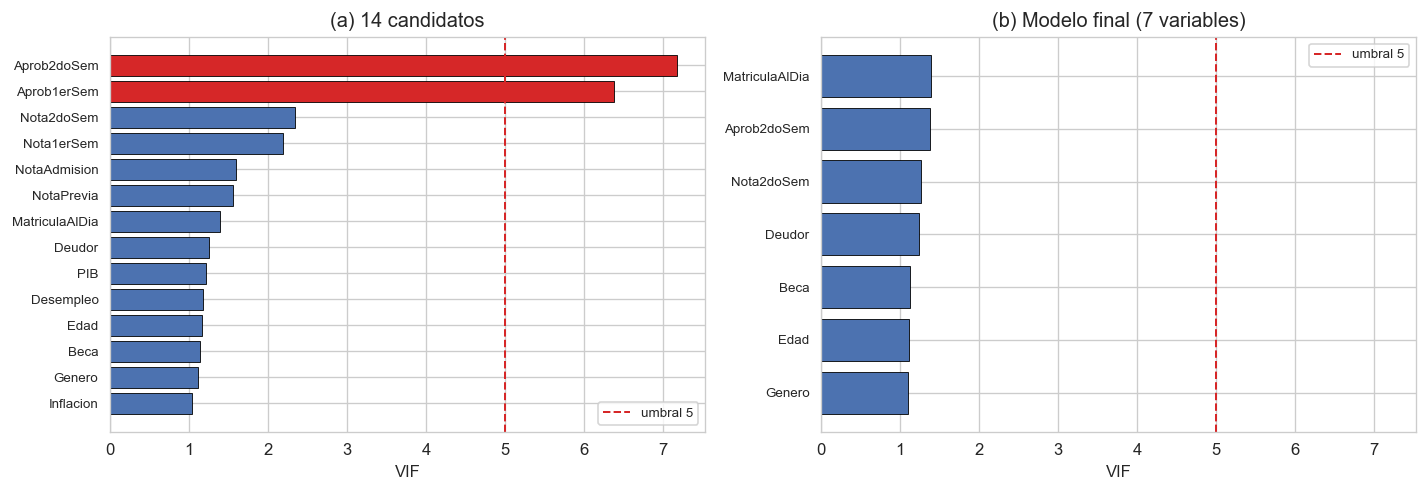

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for a, vv, tt in [(ax[0], vif_full.sort_values(), '(a) 14 candidatos'),
                  (ax[1], vif_fin.sort_values(), '(b) Modelo final (7 variables)')]:
    colors = ['#d62728' if v > 5 else BOOT_COLOR for v in vv]
    a.barh(range(len(vv)), vv, color=colors, edgecolor='black', lw=0.5)
    a.axvline(5, color='#d62728', ls='--', lw=1.2, label='umbral 5')
    a.set_yticks(range(len(vv)))
    a.set_yticklabels(vv.index, fontsize=8)
    a.set_xlabel('VIF')
    a.set_title(tt)
    a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig15_vif.png', dpi=150, bbox_inches='tight')
plt.show()

**Multicolinealidad.** En el conjunto de 14 candidatos, las unidades aprobadas de ambos
semestres superan el umbral (VIF $6,4$ y $7,2$): correlacionan $0,92$ entre sí. 
La redundancia es **real**: el desempeño del 1er semestre
persiste en el 2do. La solución no es corregir códigos sino **no incluir ambas**, y eso es
exactamente lo que la selección de variables hizo: en el modelo final todos los VIF quedan
bajo $1,4$, sin colinealidad problemática.

**Linealidad en el logit (Box-Tidwell).** El test rechaza linealidad para las tres variables
continuas del modelo final (*Aprob2doSem*, *Nota2doSem*, *Edad*, $p < 0,0001$ en las tres). No es un
resultado sorpresivo: *Aprob2doSem* es un conteo con un quiebre de comportamiento marcado en 0
(no aprobar ninguna unidad predice deserción de forma casi determinística, mientras que entre
quienes aprueban al menos una la relación es más gradual) y *Nota2doSem* hereda el mismo patrón
por construcción (nota y aprobación están mecánicamente ligadas). El logit lineal captura la
dirección del efecto pero no esta no linealidad de umbral, se declara como limitación
estructural del modelo lineal, no del análisis: una especificación con términos cuadráticos o
la variable de conteo discretizada en tramos ($0 / 1$ a $n / todas$) podría mejorar el ajuste
local, quedando como extensión futura.

**Observaciones influyentes (distancia de Cook).** El $8{,}0\%$ de las observaciones de
entrenamiento ($203$ de $2.541$) supera el umbral convencional $4/n$, con una distancia de Cook
máxima de $0,016$ (muy por debajo de 1), el umbral de preocupación severa, y del orden de
magnitud reportado en S2 para el análisis jackknife univariado. No se eliminan: se
documentan como fuente de heterogeneidad esperable en un modelo con variables de conteo de
comportamiento no lineal, consistente con el hallazgo de Box-Tidwell anterior.

### 2.5 Evaluación de desempeño predictivo (entrenamiento y prueba)

In [18]:
cm_tr = confusion_matrix(ytr, best['yhat_tr'])
cm_te = confusion_matrix(yte, best['yhat'])
print('Matriz de confusión - ENTRENAMIENTO')
print(cm_tr)
print(f"  acc={accuracy_score(ytr, best['yhat_tr']):.3f}  "
      f"prec={precision_score(ytr, best['yhat_tr']):.3f}  "
      f"recall={recall_score(ytr, best['yhat_tr']):.3f}  "
      f"AUC={best['auc_tr']:.3f}")
print('\nMatriz de confusión - PRUEBA')
print(cm_te)
print(f"  acc={best['acc']:.3f}  prec={best['prec']:.3f}  "
      f"recall={best['rec']:.3f}  AUC={best['auc']:.3f}")

Matriz de confusión - ENTRENAMIENTO
[[1452   94]
 [ 189  806]]
  acc=0.889  prec=0.896  recall=0.810  AUC=0.923

Matriz de confusión - PRUEBA
[[613  50]
 [ 61 365]]
  acc=0.898  prec=0.880  recall=0.857  AUC=0.938


#### Figura 16. Curvas ROC y matrices de confusión del modelo final

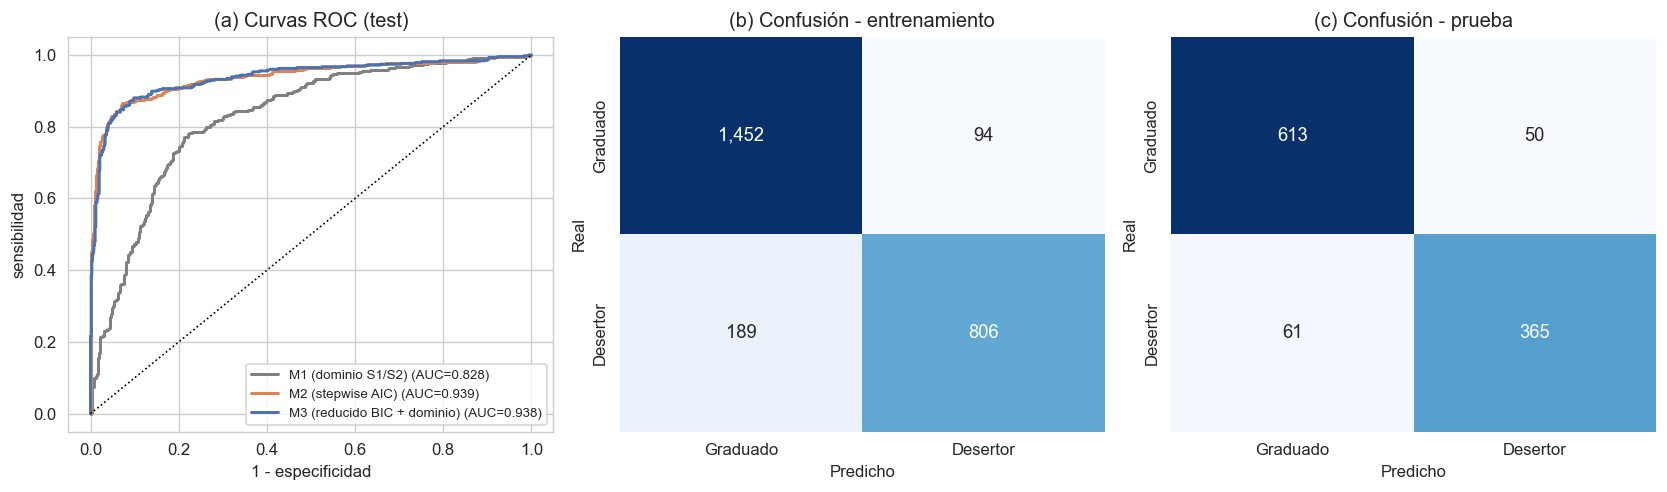

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for M, c in [(M1, 'gray'), (M2, PERM_COLOR), (M3, BOOT_COLOR)]:
    fpr, tpr, _ = roc_curve(yte, M['pte'])
    ax[0].plot(fpr, tpr, color=c, lw=1.8, label=f"{M['name']} (AUC={M['auc']:.3f})")
ax[0].plot([0, 1], [0, 1], color='black', ls=':', lw=1)
ax[0].set_title('(a) Curvas ROC (test)')
ax[0].set_xlabel('1 - especificidad')
ax[0].set_ylabel('sensibilidad')
ax[0].legend(fontsize=8, loc='lower right')

for a, cm, tt in [(ax[1], cm_tr, '(b) Confusión - entrenamiento'),
                  (ax[2], cm_te, '(c) Confusión - prueba')]:
    sns.heatmap(cm, annot=True, fmt=',', cbar=False, cmap='Blues',
                xticklabels=['Graduado', 'Desertor'],
                yticklabels=['Graduado', 'Desertor'], ax=a,
                annot_kws={'fontsize': 11})
    a.set_xlabel('Predicho')
    a.set_ylabel('Real')
    a.set_title(tt)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig16_desempeno.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo final alcanza **AUC $0,938$ en prueba** ($0,923$ en entrenamiento, la ausencia de
brecha descarta sobreajuste, confirmado por la CV). Con umbral $0,5$ clasifica correctamente
el $89{,}8\%$ de los casos, detecta el $85{,}7\%$ de los desertores (recall) y el $88{,}0\%$ de las
alarmas son verdaderas (precisión). En el contexto de negocio el costo de un falso negativo
(no detectar a un estudiante que abandonará, perdiendo la ventana de intervención) supera
al de un falso positivo (ofrecer apoyo a quien igual se graduaría, un costo menor e
incluso beneficioso), por lo que en producción convendría bajar levemente el umbral para
subir el recall, con un desbalance moderado ($39\%$) la accuracy no es engañosa, pero el AUC
sigue siendo la métrica de referencia por ser insensible al umbral.